# 1D Advection using Physics informed Deep Operator Network (PI-DeepONets) in Neuromancer

We model 1D linear advection (constant‑speed transport) on a finite space–time domain:
$$
u_t + u_x = 0,\quad x \in [0,1],; t \in [0,1].
$$

Physical meaning

This equation describes a wave profile $u(x,t)$ that moves to the right with unit speed and does not change shape.
If the initial profile at $t=0$ is $u(x,0)=v(x)$, then the solution is a translated copy:
$$
u(x,t) = v(x - t).
$$

## Deep Operator Networks (DeepONets)

DeepONets are neural networks designed to learn **operators**, i.e. mappings between functions,
$$
\mathcal{G}: v(x) \mapsto u(x,t),
$$
i.e., given any initial condition $v(x)$, predict the entire spatio‑temporal field $u(x,t)$.


### Example inspiration

[1] https://github.com/lululxvi/deepxde/blob/master/examples/operator/advection_aligned_pideeponet.py


# 1D Advection equation - Aligned Dataset

This tutorial demonstrates the use of learning Physics informed DeepONets (PI-DeepONets). This tutorial demonstrates usage of a Cartesian-product DeepONet from DeepXDE library within Neuromancer. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

### Install (Colab only)

In [1]:
# %pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"
# %pip install watermark

### Imports

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

os.environ["DDE_BACKEND"] = "pytorch"
import deepxde as dde

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [3]:
# PyTorch random seed
torch.manual_seed(1234)

# NumPy random seed
np.random.seed(1234)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Problem definition

PDE Definition:

The PDE is the 1D advection equation: 
$$(\frac{\partial y}{\partial t} + \frac{\partial y}{\partial x} = 0)$$

where $y(x, t)$ is the solution, $x$ is spatial coordinate, and $t$ is time.
This represents wave propagation without diffusion, with the solution advecting in the positive x-direction.

In [4]:
# Poisson equation: u_x + u_t = 0
def pde(x, y, v):
    dy_x = dde.grad.jacobian(y, x, j=0)
    dy_t = dde.grad.jacobian(y, x, j=1)
    return dy_t + dy_x

### Geometry and Boundary Conditions:

- Spatial domain: Interval ([0, 1]) for (x).
- Time domain: TimeDomain ([0, 1]) for (t).
- Combined geometry: geomtime = `dde.geometry.GeometryXTime(geom, timedomain)`, a spatiotemporal domain.

In [5]:
# Domain is interval [0, 1] in both space and time
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

### Initial condition (IC): 
At $t=0$, 
$y(x, 0) = v(x)$, where $v(x)$ is a function from a function space generated later in the notebook

In [6]:
def func_ic(x, v):
    return v


ic = dde.icbc.IC(geomtime, func_ic, lambda _, on_initial: on_initial)

## Dataset Prep

Create a `dde.data.TimePDE` object for time-dependent PDEs. It samples 250 points in the domain, 50 on the initial boundary at $t=0$, and 500 test points for evaluation.


In [7]:
# Define PDE
pde = dde.data.TimePDE(geomtime, pde, ic, num_domain=250, num_initial=50, num_test=500)

Training points:
- `train_x_all`: ~250 interior spatio‑temporal points + 50 initial points ($t=0$).
- `train_x_bc`: the IC points (≈50) filtered from `train_x_all`.
- `train_x`: `train_x_bc` stacked with `train_x_all` (IC points appear twice because BC and PDE losses use separate slices).


Test points:
- `test_x`: `train_x_bc` + 400 uniformly sampled interior points

In [8]:
n_bc = sum(pde.num_bcs)
print(n_bc)
print("train_x", pde.train_x.shape)
print("train_x_all", pde.train_x_all.shape)
print("train_x_bc", pde.train_x_bc.shape)  # (350, 2)
print("test_x ", pde.test_x.shape)
print("BC x identical on test/train? ", np.allclose(pde.test_x[:n_bc], pde.train_x_bc))

50
train_x (350, 2)
train_x_all (300, 2)
train_x_bc (50, 2)
test_x  (556, 2)
BC x identical on test/train?  True


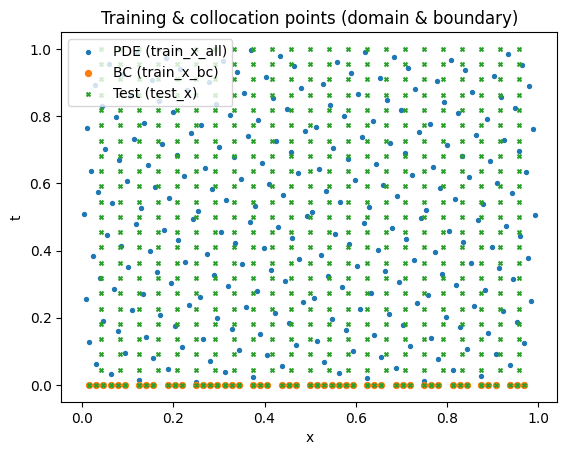

In [9]:
# grab points, display x-cordinates

plt.figure()
plt.scatter(
    pde.train_x_all[:, 0], pde.train_x_all[:, 1], s=8, label="PDE (train_x_all)"
)
plt.scatter(pde.train_x_bc[:, 0], pde.train_x_bc[:, 1], s=18, label="BC (train_x_bc)")
plt.scatter(pde.test_x[:, 0], pde.test_x[:, 1], s=8, marker="x", label="Test (test_x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Training & collocation points (domain & boundary)")
plt.legend()
##plt.show()

## Initial conditions generation

Initial conditions Sample $v(x)$ are sampled from a Gaussian random field (GRF) over ([0,1]).

Use the [GRF data generator from dde](https://deepxde.readthedocs.io/en/latest/_modules/deepxde/data/function_spaces.html#GRF) to sample a chosen dataset size.

Each $v(x)$ is discretized by evaluating it at a fixed set of sensor points `eval_pts`, forming the branch input to the DeepONet.

In [10]:
# Function space with N=1000 (default)
func_space = dde.data.GRF(kernel="ExpSineSquared", length_scale=1)

Text(0, 0.5, 'v(x)')

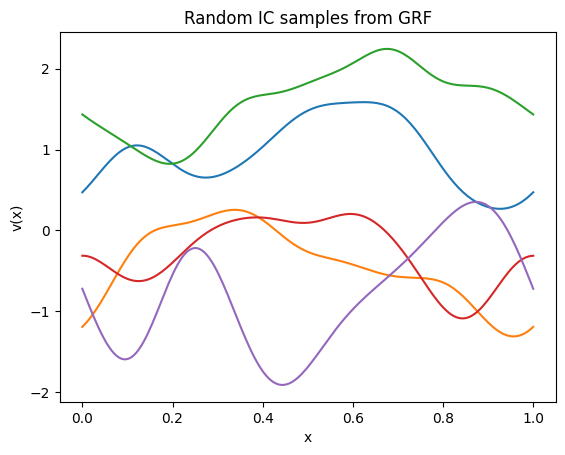

In [11]:
# 2) Sample a few GRF functions (input ICs)
xs = np.linspace(0, 1, 200)[:, None]
feats = func_space.random(5)
vals = func_space.eval_batch(feats, xs)
plt.figure()
for i in range(vals.shape[0]):
    plt.plot(xs.ravel(), vals[i])
plt.title("Random IC samples from GRF")
plt.xlabel("x")
plt.ylabel("v(x)")

50 evenly spaced evaluation points in $[0, 1]$ for $x$

In [12]:
# Data
eval_pts = np.linspace(0, 1, num=50)[:, None]

`PDEOperatorCartesianProd` from `dde` builds the operator-learning dataset

It samples `num_function` random f from `function_space`, evaluates them at `evaluation_points` for branch inputs, evaluates them at all PDE collocation points for auxiliary vars, and pairs each branch sample with the fixed trunk grid.

After construction, `data` contains the following fields:

- **`data.eval_pts`**  
  The evaluation points used to sample each function $f$ for the branch network.  
  Shape: `(num_eval_points,) = (50,)`

- **`data.train_x`**  
  Tuple `(func_vals, pde.train_x)` containing branch and trunk inputs.

  - **`func_vals`**  
    Branch inputs: values of each sampled function evaluated at `eval_pts`.  
    Shape: `(num_function, num_eval_points) = (1000, 50)`

  - **`pde.train_x`**  
    Trunk inputs: PDE collocation points in $(x,t)$ (interior + boundary).  
    Shape: `(num_domain + num_boundary, dim) = (350, 2)`

In [ ]:
# Define PDE operator
data = dde.data.PDEOperatorCartesianProd(
    pde,
    function_space=func_space,
    evaluation_points=eval_pts,
    num_function=1000,
    function_variables=[0],
    num_test=100,
    batch_size=32,
)

In [14]:
# Branch inputs: f values at the 10 evaluation points
f_vals, x_trunk = data.train_x  # f_vals shape: (1000, 350); x_trunk shape: (350, 2)
eval_pts = data.eval_pts  # same 10-point grid used for branch inputs
f_trunk = data.train_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid
print("eval_pts.shape ", eval_pts.shape)
print("x_trunk.shape ", x_trunk.shape)
print("f_vals.shape    ", f_vals.shape)
print("f_trunk.shape ", f_trunk.shape)

eval_pts.shape  (50, 1)
x_trunk.shape  (350, 2)
f_vals.shape     (1000, 50)
f_trunk.shape  (1000, 350)


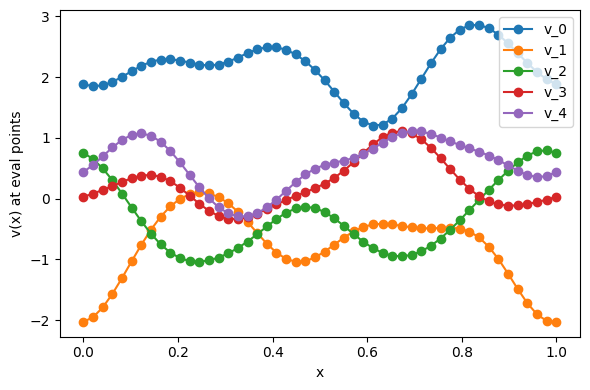

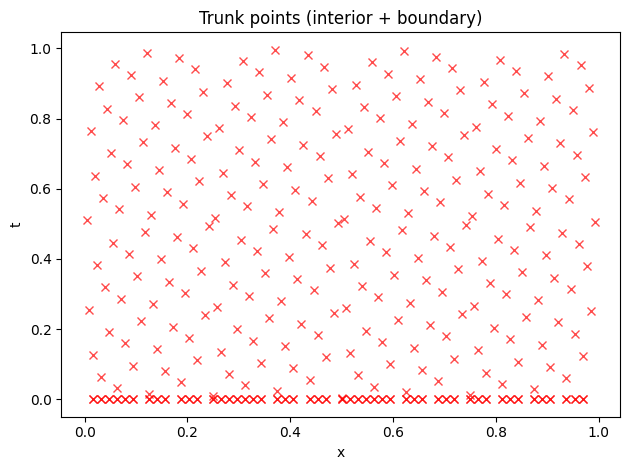

In [15]:
# Plot a few sampled source terms on the eval grid
plt.figure(figsize=(6, 4))
for i in range(5):
    plt.plot(eval_pts[:, 0], f_vals[i], marker="o", label=f"v_{i}")
plt.xlabel("x")
plt.ylabel("v(x) at eval points")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize trunk (PDE collocation + boundary) points
# plt.figure(figsize=(6, 2))
plt.plot(x_trunk[:, 0], x_trunk[:, 1], "rx", alpha=0.7)
# plt.yticks([])
plt.xlabel("x")
plt.ylabel("t")
plt.title("Trunk points (interior + boundary)")
plt.tight_layout()
plt.show()

In [16]:
## Create data for testing
(f_vals_test, x_trunk_test) = data.test_x
f_trunk_test = data.test_aux_vars  # (Nf, m_trunk) = f(x) on trunk grid

In [17]:
print("x_trunk_test.shape ", x_trunk_test.shape)
print("f_vals_test.shape    ", f_vals_test.shape)
print("f_trunk_test.shape ", f_trunk_test.shape)

x_trunk_test.shape  (556, 2)
f_vals_test.shape     (100, 50)
f_trunk_test.shape  (100, 556)


## Creating datasets for Neuromancer

Branch net consumes the sampled initial condition $v(x)$ at `eval_pts`.
Trunk net consumes the query point $(x,t)$.

- Branch input shape (`num_function, eval_pts`) = (1000,50): values of each sampled function at the 50 evaluation points.
- Trunk input shape (`num_pde_pts`, `dim_x`) = (`pde.train_x.shape[0]`, `2`): spatial coordinates used for PDE residual + IC enforcement.

`requires_grad_()` here ensures the trunk coords participate in autograd if we differentiate `u(x)`. This may be needed for physics losses in some cases.

In [18]:
from neuromancer.dataset import DictDataset

branch_inputs = torch.as_tensor(f_vals, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid = torch.as_tensor(x_trunk, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs = trunk_grid.expand(
    branch_inputs.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk = torch.as_tensor(f_trunk, dtype=torch.float32)  # (Nf, m_trunk)

train_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs,
        "trunk_inputs": trunk_inputs,
        "outputs": f_out_trunk,
    },
    name="train",
)

In [19]:
branch_inputs_test = torch.as_tensor(f_vals_test, dtype=torch.float32)  # (Nf, m_eval)
trunk_grid_test = torch.as_tensor(x_trunk_test, dtype=torch.float32)  # (m_trunk, dim_x)
trunk_inputs_test = trunk_grid_test.expand(
    branch_inputs_test.shape[0], -1, -1
).requires_grad_()  # (Nf, m_trunk, dim_x) shared grid, grad on for physics loss
f_out_trunk_test = torch.as_tensor(f_trunk_test, dtype=torch.float32)  # (Nf, m_trunk)

test_datadict = DictDataset(
    {
        "branch_inputs": branch_inputs_test,
        "trunk_inputs": trunk_inputs_test,
        "outputs": f_out_trunk_test,
    },
    name="test",
)

In [ ]:
# creating dev_datadict from test_datadict (20 samples) - leaves test_datadict (80 samples)
dev_size = 20
dev_idx = torch.arange(dev_size)
test_idx = torch.arange(dev_size, len(test_datadict))

dev_datadict = DictDataset(
    {k: v[dev_idx] for k, v in test_datadict.datadict.items()},
    name="dev",
)
test_datadict = DictDataset(
    {k: v[test_idx] for k, v in test_datadict.datadict.items()},
    name="test",
)

### Create named dictionary datasets

In [ ]:
# check dimensions
print("Dimensions check:")
print("Train branch:", train_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Train output:", train_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Train trunk:", train_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

print("Test branch:", test_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Test output:", test_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print(
    "Test trunk:", test_datadict.datadict["trunk_inputs"].shape
)  # (Nf, m_trunk, dim_x)

print("Dev branch:", dev_datadict.datadict["branch_inputs"].shape)  # (Nf, m_eval)
print("Dev output:", dev_datadict.datadict["outputs"].shape)  # (Nf, m_trunk)
print("Dev trunk:", dev_datadict.datadict["trunk_inputs"].shape)  # (Nf, m_trunk, dim_x)

Dimensions check:
Train branch: torch.Size([1000, 50])
Train output: torch.Size([1000, 350])
Train trunk: torch.Size([1000, 350, 2])
Test branch: torch.Size([80, 50])
Test output: torch.Size([80, 556])
Test trunk: torch.Size([80, 556, 2])
Dev branch: torch.Size([20, 50])
Dev output: torch.Size([20, 556])
Dev trunk: torch.Size([20, 556, 2])


### Create torch DataLoaders for the Trainer

In [22]:
batch_size = 32
print(f"batch_size: {batch_size}")
train_loader = torch.utils.data.DataLoader(
    train_datadict,
    batch_size=batch_size,
    collate_fn=train_datadict.collate_fn,
    shuffle=False,
)

dev_loader = torch.utils.data.DataLoader(
    dev_datadict,
    batch_size=batch_size,
    collate_fn=dev_datadict.collate_fn,
    shuffle=False,
)

test_loader = torch.utils.data.DataLoader(
    test_datadict,
    batch_size=batch_size,
    collate_fn=test_datadict.collate_fn,
    shuffle=False,
)

batch_size: 32


# Define DeepONet

The branch net is chosen as a fully connected neural network of size `[eval_pts_shape, 128, 128, 128]`, and the the trunk net is a fully connected neural network of size `[dim_x, 128, 128, 128]`, where `dim_x` is dimension i.e. 2.

## Exporting DeepONet from DeepXDE in Neuromancer

We use the DeepONets available in the `dde.nn` from [DeepXDE](https://deepxde.readthedocs.io/en/latest/) library within Neuromancer. Here, we use `dde.nn.DeepONetCartesianProd` with the PyTorch backend `os.environ["DDE_BACKEND"] = "pytorch"`

In [23]:
# Setup DeepONet
dim_x = 2  # (x, t)
eval_pts_shape = eval_pts.shape[0]
dde_deeponet = dde.nn.DeepONetCartesianProd(
    [eval_pts_shape, 128, 128, 128],
    [dim_x, 128, 128, 128],
    activation="tanh",  # activation function
    kernel_initializer="Glorot normal",  # weighted initialization
)

Another way to encode spatial features is making use of the periodic nature.

The PDE solution is periodic in $x$, so Fourier features make structure easier to learn. We use the `apply_feature_transform` on the DeepONet to enrich the feature space. This will change the trunk dimension to `dim_x=5`. 

In [24]:
def periodic(x):
    """
    Input: x is the trunk input with shape (N, 2) containing [x, t].
    It splits into x and t, rescales x to [0, 2π].
    It builds a Fourier-style embedding of x:
    [cos(x), sin(x), cos(2x), sin(2x)]
    Then it appends t back.
    Output shape: (N, 5)
    """
    x, t = x[:, :1], x[:, 1:]
    x = x * 2 * np.pi
    return torch.cat(
        [torch.cos(x), torch.sin(x), torch.cos(2 * x), torch.sin(2 * x), t], 1
    )

In [25]:
dim_x_fourier = 5  # Fourier features: [cos(x), sin(x), cos(2x), sin(2x), t]
eval_pts_shape = eval_pts.shape[0]
dde_deeponet_fourier = dde.nn.DeepONetCartesianProd(
    [eval_pts_shape, 128, 128, 128],
    [dim_x_fourier, 128, 128, 128],
    activation="tanh",  # activation function
    kernel_initializer="Glorot normal",  # weighted initialization
)
dde_deeponet_fourier.apply_feature_transform(periodic)


A wrapper is needed for the DictDataset format to work with DeepXDE models.
`DeepXDEDataWrapper` makes DeepXDE models compatible with NeuroMANCER Nodes. DeepXDE expects a single tuple/list input (branch_inputs, trunk_inputs)

In [26]:
from neuromancer.modules.operators import DeepXDEWrapper
from neuromancer.system import Node

dde_deeponet_wrapped = DeepXDEWrapper(
    model=dde_deeponet_fourier,  # dde_deeponet or dde_deeponet_fourier
    is_cartesian=True,
)

node_dde_deeponet = Node(
    dde_deeponet_wrapped,
    ["branch_inputs", "trunk_inputs"],
    ["g"],
    name="dde_deeponet",
)
print(node_dde_deeponet)

dde_deeponet(branch_inputs, trunk_inputs) -> g


### Forward pass

In [27]:
print("symbolic inputs:", node_dde_deeponet.input_keys)
print("symbolic outputs:", node_dde_deeponet.output_keys)

symbolic inputs: ['branch_inputs', 'trunk_inputs']
symbolic outputs: ['g']


In [28]:
# evaluate forward pass on the train data
net_out = node_dde_deeponet(train_datadict.datadict)
net_out["g"].shape

torch.Size([1000, 350])

## Physics informed losses using Constraints in NeuroMANCER

How physics is enforced:

No boundary conditions are imposed; only the initial condition at ($t=0$).
Training minimizes a physics‑informed loss:
- PDE residual: $|u_t + u_x|^2$ at interior space–time collocation points.
- Initial condition: $|u(x,0) - v(x)|^2$ at points on ($t=0$).

In [29]:
from neuromancer.problem import Problem
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss

# Vars
u = variable("g")  # DeepONet output u(x,t)
xt = variable("trunk_inputs")  # (B, m, 2) with requires_grad=True
v = variable("outputs")  # v(x) values on trunk grid (from PDEOperator)
num_bc = sum(pde.num_bcs)  # number of IC points at t=0

In [30]:
# Derivatives
du_dxt = u.grad(xt)  # (B, m, 2)
u_x = du_dxt[..., 0]
u_t = du_dxt[..., 1]

In [31]:
# check the shapes of the forward pass of the symbolic DeepONet terms
print(du_dxt({**net_out, **train_datadict.datadict}).shape)
print(u_x({**net_out, **train_datadict.datadict}).shape)
print(u_t({**net_out, **train_datadict.datadict}).shape)
print(v({**net_out, **train_datadict.datadict}).shape)

torch.Size([1000, 350, 2])
torch.Size([1000, 350])
torch.Size([1000, 350])
torch.Size([1000, 350])


In [32]:
# PDE loss on interior slice (train_x_all)
res_pde = (u_t + u_x)[:, num_bc:]  # PDE points only
pde_loss = (res_pde == 0.0) ^ 2
# Use this to remove braodcasting errors
# pde_loss = (res_pde == torch.zeros_like(res_pde)) ^ 2

pde_loss.name = "pde_residual"

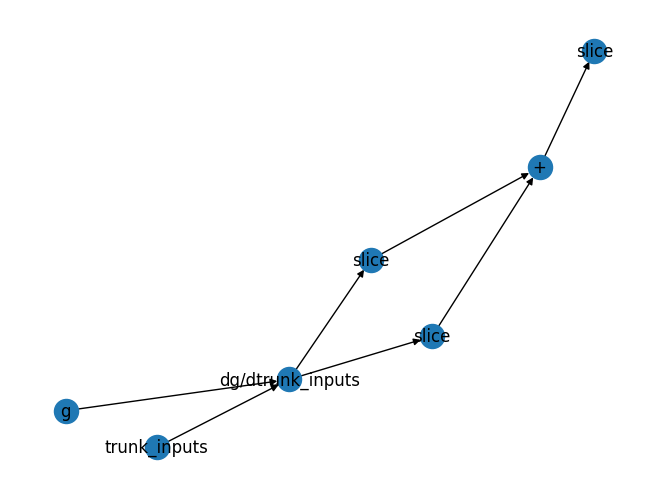

In [33]:
res_pde.show()

In [34]:
# IC loss on boundary slice (train_x_bc)
u_ic = u[:, :num_bc]
v_ic = v[:, :num_bc]  # v(x) at t=0 points
ic_loss = (u_ic == v_ic) ^ 2
ic_loss.name = "ic"

In [35]:
print(v_ic({**net_out, **train_datadict.datadict}).shape)
print(u_ic({**net_out, **train_datadict.datadict}).shape)

torch.Size([1000, 50])
torch.Size([1000, 50])


In [36]:
loss = PenaltyLoss(objectives=[pde_loss, ic_loss], constraints=[])

`Problem` setup using both DeepONets is similar. The Neuromancer library gives you the choice of seamlessly adding any approximator of choice in your `Problem` framework

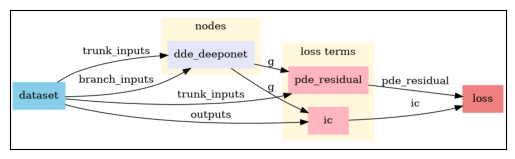

In [37]:
problem = Problem(
    nodes=[node_dde_deeponet],  # list of nodes (neural nets) to be optimized
    loss=loss,  # physics-informed loss function
    grad_inference=True,
)  # argument for allowing computation of gradients at the inference time)
problem.show()  # graphviz library needed for graph visualization

## Problem Solution in NeuroMANCER

We suggest training this problem for atleast 2000 epochs with 5 trunk net features to see accurate results.

In [38]:
lr = 0.0005  # step size for gradient descent
epochs = 1000  # number of training epochs (needs many epochs to converge)
epoch_verbose = 10  # print loss/display loss plot when this many epochs have occurred
warmup = 200  # number of epochs to wait before enacting early stopping policy
patience = 200  # number of epochs with no improvement in eval metric to allow before early stopping

optimizer = torch.optim.Adam(problem.parameters(), lr=lr)


### Construct Trainer and solve the problem

In [ ]:
from neuromancer.trainer import Trainer
from neuromancer.callbacks import LossHistoryCallback

# define loss history callback using plots
loss_history_callback = LossHistoryCallback(plots_dir=None, show=True)

# define trainer
trainer = Trainer(
    problem.to(device),
    train_data=train_loader,
    dev_data=dev_loader,  # just a placeholder for dev set
    test_data=test_loader,  # optional test data for evaluating test losses
    optimizer=optimizer,
    logger=None,
    callback=loss_history_callback,
    epochs=epochs,
    patience=patience,
    epoch_verbose=epoch_verbose,
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="test_loss",
    eval_metric="mean_train_loss",
    warmup=warmup,
    device=device,
)

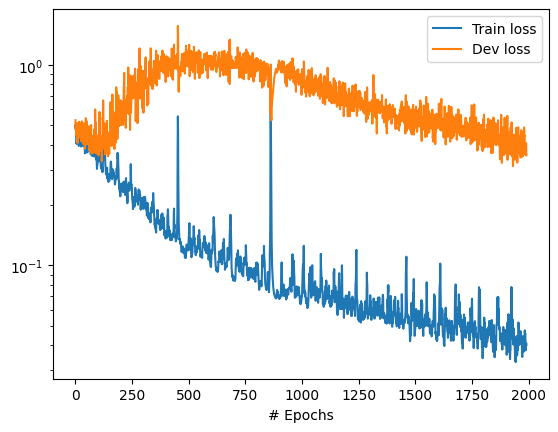

CPU times: user 3min 35s, sys: 35.1 s, total: 4min 10s
Wall time: 4min 14s


In [47]:
%%time
best_model = trainer.train()

In [48]:
# load best trained model
problem.load_state_dict(best_model)

# if using test_loader
best_outputs = trainer.test(best_model)

In [ ]:
train_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["train"]]
print(f"len(train_loss_history): {len(train_loss_history)}")

# if using dev_loader
dev_loss_history = [l.detach().cpu().numpy() for l in trainer.loss_history["dev"]]
print(f"len(dev_loss_history): {len(dev_loss_history)}")

# if using test_loader
mean_test_loss = best_outputs["mean_test_loss"].detach().cpu().numpy()
print(mean_test_loss)


len(train_loss_history): 2000
len(dev_loss_history): 2000
0.33243585


## Plot loss history w/ mean test loss

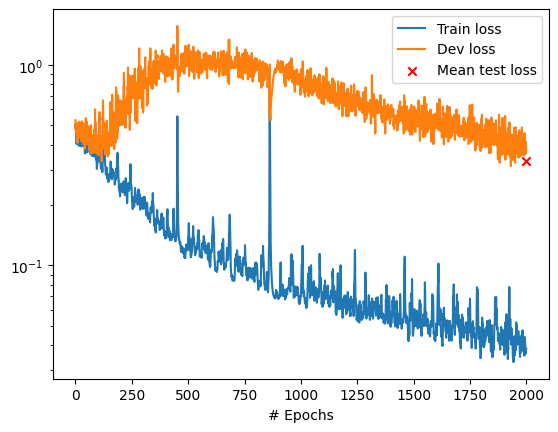

In [50]:
plt.semilogy(train_loss_history, label="Train loss")
plt.semilogy(dev_loss_history, label="Dev loss")
plt.scatter(
    len(train_loss_history), mean_test_loss, label="Mean test loss", c="red", marker="x"
)
plt.xlabel("# Epochs")
plt.legend()
plt.show()

## Compare results on unseen test data

We do not use the `test_loader` formulated previously. This is a physics informed problem, so we try it on unseen freshly generated data.

Compare model predictions to the analytic solution $u(x, t) = sin(2π(x − t))$ on irregular collocation points using triangulated contours.


In [ ]:
# Postproc from scratch on a regular grid
problem.eval()

# Grid for visualization
x = np.linspace(0, 1, num=100)
t = np.linspace(0, 1, num=100)
xv, tv = np.meshgrid(x, t)

# Analytic solution on the grid
u_true = np.sin(2 * np.pi * (xv - tv))

# Branch input v(x) sampled at eval_pts (same eval grid used in training)
# eval_pts should be shape (m_eval, 1)
v_branch_np = np.sin(2 * np.pi * eval_pts[:, 0])[None, :]  # (1, m_eval)

# Trunk inputs: (1, m_trunk, 2)
x_trunk = np.stack([xv.ravel(), tv.ravel()], axis=-1)  # (m_trunk, 2)
xt = torch.tensor(x_trunk, dtype=torch.float32, device=device).unsqueeze(0)
v = torch.tensor(v_branch_np, dtype=torch.float32, device=device)

with torch.no_grad():
    res = problem.predict({"branch_inputs": v, "trunk_inputs": xt})
u_pred = res["g"][0].detach().cpu().numpy().reshape(len(t), len(x))


Relative L2 error: 1.7309e-01


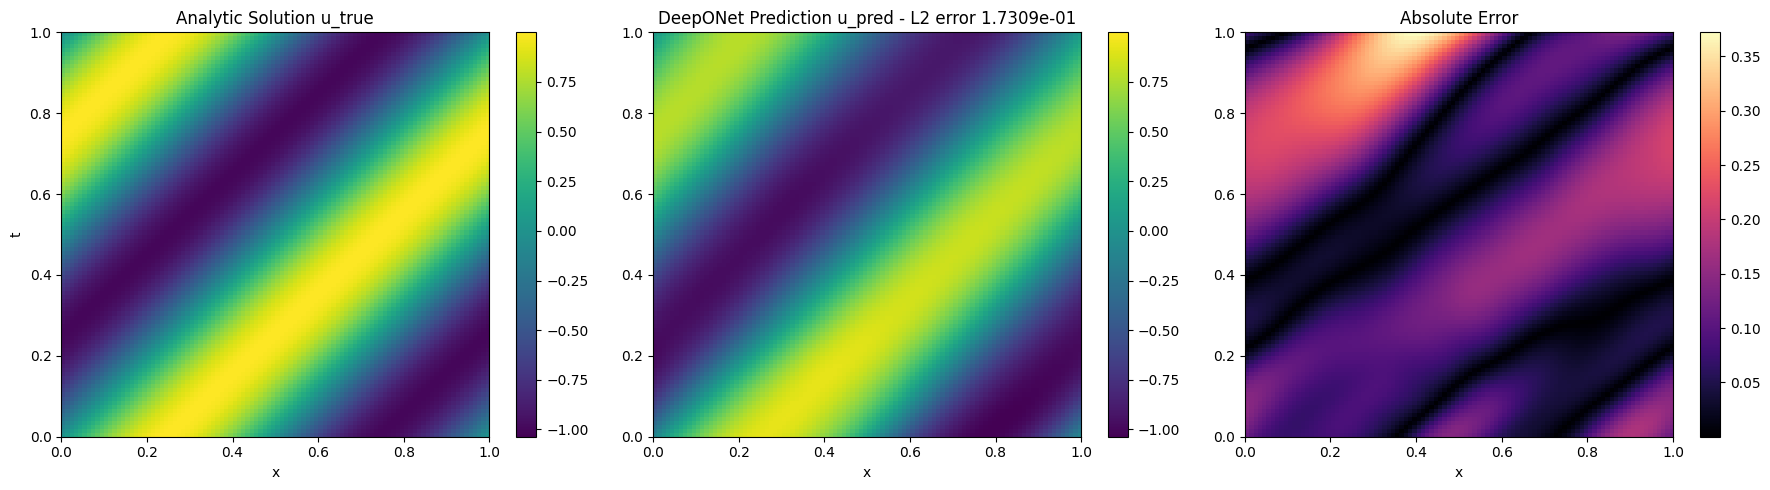

In [56]:
# Calculate error map
error = np.abs(u_true - u_pred)

# Relative L2 error
rel_l2 = np.linalg.norm(u_true - u_pred) / np.linalg.norm(u_true)
print(f"Relative L2 error: {rel_l2:.4e}")

# Setup the figure with 3 subplots
# Plot
vmin = min(u_true.min(), u_pred.min())
vmax = max(u_true.max(), u_pred.max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Common parameters for the solution plots
plot_params = {
    "origin": "lower",
    "aspect": "auto",
    "vmin": vmin,
    "vmax": vmax,
    "extent": [0, 1, 0, 1],
}

# 1. Plot True Solution
im1 = axes[0].imshow(u_true, **plot_params)
axes[0].set_title("Analytic Solution u_true")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
fig.colorbar(im1, ax=axes[0])

# 2. Plot Predicted Solution
im2 = axes[1].imshow(u_pred, **plot_params)
axes[1].set_title(f"DeepONet Prediction u_pred - L2 error {rel_l2:.4e}")
axes[1].set_xlabel("x")
fig.colorbar(im2, ax=axes[1])

# 3. Plot Absolute Error
im3 = axes[2].imshow(
    error, origin="lower", aspect="auto", cmap="magma", extent=[0, 1, 0, 1]
)
axes[2].set_title("Absolute Error")
axes[2].set_xlabel("x")
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()
